# ResNet50

In [1]:
import tarfile
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import shutil

import numpy as np
import seaborn as sns
from tensorflow import keras
# Import ResNet50 và các hàm chuẩn hóa đi kèm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

2026-06-20 17:07:49.715271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781975269.905909      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781975269.960047      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781975270.429332      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781975270.429387      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781975270.429391      23 computation_placer.cc:177] computation placer alr

## Model Exploration


In [2]:
resnet50 = ResNet50(weights='imagenet', input_shape=(224, 224, 3))

I0000 00:00:1781975296.875758      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781975296.881943      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


102967424/102967424 [==============================] - 1s 0us/step


In [3]:
# sample_image = keras.preprocessing.image.load_img('../data/raw/Lion.jpg',
#                                                   target_size=(224, 224))

# # ResNet50 yêu cầu ảnh được chuẩn hóa qua hàm preprocess_input
# sample_image = np.array(sample_image)
# sample_image_preprocessed = preprocess_input(np.expand_dims(sample_image, axis=0))

# predicted_class = resnet50.predict(sample_image_preprocessed)
# predicted_class = decode_predictions(predicted_class, top=1)
# predicted_class = np.ravel(predicted_class)

# plt.imshow(sample_image)
# plt.title("Predicted class: " + predicted_class[1])
# plt.axis('off')
# plt.show()

## Data Exploration

After downloading our dataset from Tensorflow's repository, we need to split it between training (including validation) and testing sets. As every image is downloaded in a single folder, we can just select a percentage of them and move them to a testing folder. We go with a 70/15/15 dataset split for our training session here.

In [4]:
# flowers_dataset_path = keras.utils.get_file(
#     'flower_photos.tgz',
#     origin='https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
# )

# # Unzip the file on the download path.
# tarfile_obj = tarfile.open(flowers_dataset_path)
# tarfile_obj.extractall("./")
# tarfile_obj.close()

# # Make all directories needed to create our testing set.
# os.mkdir('flower_photos_test')
# os.mkdir('flower_photos_test/daisy')
# os.mkdir('flower_photos_test/dandelion')
# os.mkdir('flower_photos_test/roses')
# os.mkdir('flower_photos_test/sunflowers')
# os.mkdir('flower_photos_test/tulips')

# # We do not need the LICENSE file, so remove it.
# try:
#     os.remove('flower_photos/LICENSE.txt')
# except OSError as e:
#     print("Error: %s - %s." % (e.filename, e.strerror))

In [5]:
# Count the number of samples to calculate a data-driven batch size.
# num_samples = 0
# for dir_path, dir_names, files in os.walk('flower_photos'):
#     num_samples += len(files)

#     for file_name in files:
#             # 15% percent chances of the number generated being smaller than 0.15
#             # the same percentage of our testing set.
#             if np.random.rand(1) < 0.15:
#                 # Đường dẫn file hiện tại (nguồn)
#                 src_path = os.path.join(dir_path, file_name)
                
#                 # Tạo đường dẫn đích bằng cách thay thế tên thư mục cha
#                 dest_dir = dir_path.replace('flower_photos', 'flower_photos_test')
#                 dest_path = os.path.join(dest_dir, file_name)
                
#                 # Di chuyển file
#                 shutil.move(src_path, dest_path)
# print("Total number of photos: ", num_samples)

Before seing what our data looks like, we can instantiate our data generators. We argue that 50 batches with 62 images is a reasonable setting for our training.

Other than that, we rescale our images to be in the [0, 1] range to help the model converge faster. Images are also expected to have their values in this range for the imported MobileNetV2 model.

In [6]:
def count_files_in_dir(path):
    """Hàm đếm tổng số file trong một thư mục và các thư mục con"""
    total_files = 0
    for dir_path, dir_names, files in os.walk(path):
        total_files += len(files)
    return total_files

# 1. Đếm số lượng ảnh trong từng thư mục
train_val_dir = '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos'
test_dir = '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos_test'

num_train_val = count_files_in_dir(train_val_dir)
num_test = count_files_in_dir(test_dir)

# 2. Tính tổng số lượng ảnh của toàn bộ dataset
total_samples = num_train_val + num_test

# 3. Tính phần trăm
if total_samples > 0:
    train_val_percent = (num_train_val / total_samples) * 100
    test_percent = (num_test / total_samples) * 100
else:
    train_val_percent = test_percent = 0

# ==========================================
# IN KẾT QUẢ
# ==========================================
print("="*40)
print(f"📊 THỐNG KÊ SỐ LƯỢNG DATASET HIỆN TẠI:")
print("="*40)
print(f"📁 Thư mục '{train_val_dir}' (Train/Val): {num_train_val} ảnh ({train_val_percent:.2f}%)")
print(f"📁 Thư mục '{test_dir}' (Test):       {num_test} ảnh ({test_percent:.2f}%)")
print("-"*40)
print(f"Total dataset: {total_samples} ảnh (100.00%)")
print("="*40)

📊 THỐNG KÊ SỐ LƯỢNG DATASET HIỆN TẠI:
📁 Thư mục '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos' (Train/Val): 3090 ảnh (84.20%)
📁 Thư mục '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos_test' (Test):       580 ảnh (15.80%)
----------------------------------------
Total dataset: 3670 ảnh (100.00%)


In [7]:
# ==========================================
# 1. TÍNH TOÁN DATA-DRIVEN BATCH SIZE
# ==========================================
# Đếm số lượng ảnh trong thư mục train (flower_photos) để tính batch size
num_training_samples = 0
for dir_path, dir_names, files in os.walk(train_val_dir):
    num_training_samples += len(files)

# Tính batch size dựa trên logic cũ của bạn (chia dữ liệu thành 50 batches)
batch_size = int(num_training_samples / 50)
if batch_size == 0:  # Tránh lỗi chia cho 0 nếu thư mục trống
    batch_size = 32

print(f"Total training/validation samples found: {num_training_samples}")
print(f"Calculated Batch Size: {batch_size}")

# ==========================================
# 2. CẤU HÌNH IMAGE DATA GENERATORS
# ==========================================
# Generator dành cho Train và Validation (có sử dụng validation_split)
train_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15  # Tách 15% từ 'flower_photos' làm tập Validation
)

# Generator dành riêng cho Test (KHÔNG có validation_split)
test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ==========================================
# 3. TẠO CÁC LUỒNG DỮ LIỆU (FLOW)
# ==========================================

# Luồng dữ liệu Training (85% của thư mục flower_photos)
train_flow = train_val_datagen.flow_from_directory(
    train_val_dir,
    batch_size=batch_size,
    target_size=(224, 224),
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Luồng dữ liệu Validation (15% của thư mục flower_photos)
validation_flow = train_val_datagen.flow_from_directory(
    train_val_dir,
    batch_size=batch_size,
    target_size=(224, 224),
    class_mode='categorical',
    subset='validation',
    shuffle=False  # Không cần shuffle khi đánh giá/validate
)

# Luồng dữ liệu Testing (100% của thư mục flower_photos_test)
test_flow = test_datagen.flow_from_directory(
    test_dir,
    batch_size=batch_size,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False  # Giữ nguyên thứ tự để dễ đánh giá predict sau này
)

Total training/validation samples found: 3090
Calculated Batch Size: 61
Found 2628 images belonging to 5 classes.
Found 462 images belonging to 5 classes.
Found 580 images belonging to 5 classes.


In the next grid, 16 random images are taken from the first batch of the training generator and plotted. This way, we can grab a look on how our images look like. Labels are printed above each image.

Since our labels are originally one-hot encoded, we use Scikit-learn's `OneHotEncoder` to quickly revert the label encoding to class names.

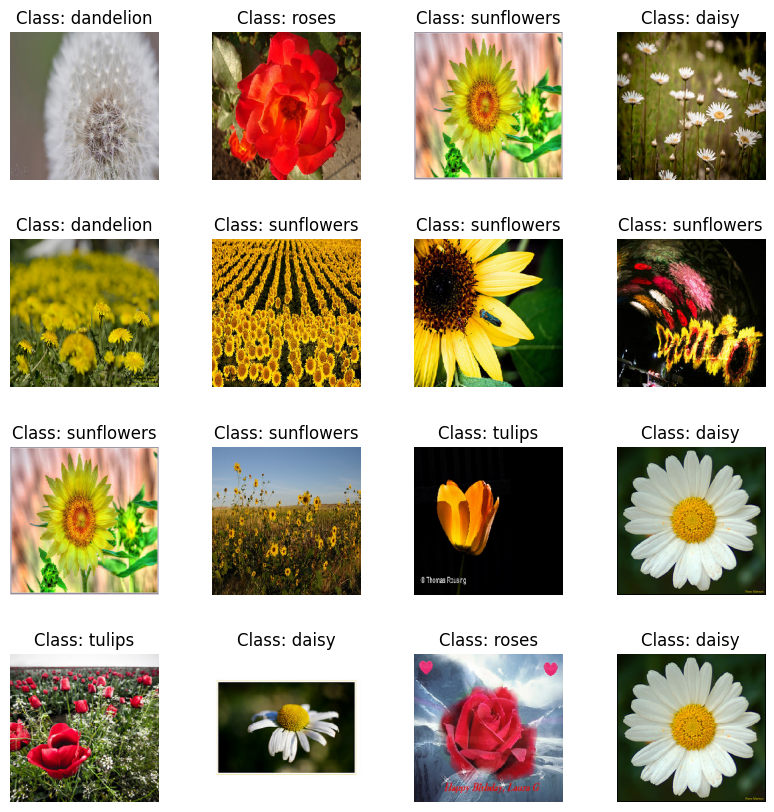

In [8]:
# Get first batch as a dataset sample to use in the grid.
grid_batch = train_flow.__getitem__(0)

# Class names to reverse the one-hot encoding.
labels = np.array(['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'])
labels = labels.reshape(-1, 1)

# Reverse one-hot encoding to plot the actual flower names in the grid.
encoder = OneHotEncoder()
encoder.fit(labels)
batch_labels = encoder.inverse_transform(grid_batch[1]).flatten()

grid_height = 4
grid_width = 4

fig, axes = plt.subplots(grid_height, grid_width, figsize=(10, 10))
axes = axes.ravel()

# Định nghĩa hàm giải chuẩn hóa để vẽ ảnh chính xác
def denormalize_image(img):
    img = img.copy()
    # preprocess_input thực hiện chuyển RGB -> BGR và trừ đi giá trị trung bình ImageNet: [103.939, 116.779, 123.68]
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    img = img[..., ::-1] # BGR -> RGB
    img = np.clip(img, 0, 255).astype('uint8')
    return img

for i in range(grid_height * grid_width):
    # Draft random sample from the training set to plot with its label.
    drafted_index = np.random.randint(0, grid_batch[0].shape[0])
    
    # Khôi phục ảnh gốc để hiển thị màu sắc đúng
    display_img = denormalize_image(grid_batch[0][drafted_index])
    axes[i].imshow(display_img)
    axes[i].set_title("Class: " + str(batch_labels[drafted_index]))
    axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

## Model Building and Training


In [9]:
# Tải phần thân mô hình ResNet50 (loại bỏ tầng phân loại trên cùng)
resnet50_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Đóng băng các trọng số để không huấn luyện lại phần thân này
resnet50_base.trainable = False

print("Example output shape from feature extractor: ")
print(resnet50_base.compute_output_shape(train_flow.__getitem__(0)[0].shape))

94765736/94765736 [==============================] - 0s 0us/step
Example output shape from feature extractor: 
(61, 2048)


In [10]:
# Tạo Sequential model với backbone là ResNet50
resnet50_retrained = keras.Sequential(
    [resnet50_base,
     # Thêm lớp Dropout chống overfitting
     keras.layers.Dropout(0.5),
     keras.layers.Dense(train_flow.num_classes, activation='softmax')]
)

resnet50_retrained.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 5)                 10245     
                                                                 
Total params: 23597957 (90.02 MB)
Trainable params: 10245 (40.02 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


In [11]:
# Cấu hình callback Early Stopping
early_stopping_cb = keras.callbacks.EarlyStopping(min_delta=0.01,
                                                  patience=10,
                                                  restore_best_weights=True)

# Biên dịch mô hình với thuật toán tối ưu Adam
resnet50_retrained.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

epochs_info = resnet50_retrained.fit(train_flow,
                                     epochs=100,
                                     validation_data=validation_flow,
                                     callbacks=[early_stopping_cb])

Epoch 1/100


I0000 00:00:1781975319.851019      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781975323.818416      69 service.cc:152] XLA service 0x7a8ee0e65120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781975323.818461      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781975323.818465      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/44 [..............................] - ETA: 6:07 - loss: 2.2934 - accuracy: 0.2459

I0000 00:00:1781975324.104235      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 [==============================] - 37s 668ms/step - loss: 0.9870 - accuracy: 0.6416 - val_loss: 0.4622 - val_accuracy: 0.8442
Epoch 2/100
44/44 [==============================] - 15s 338ms/step - loss: 0.4805 - accuracy: 0.8330 - val_loss: 0.3951 - val_accuracy: 0.8636
Epoch 3/100
44/44 [==============================] - 15s 341ms/step - loss: 0.3882 - accuracy: 0.8611 - val_loss: 0.3585 - val_accuracy: 0.8766
Epoch 4/100
44/44 [==============================] - 15s 335ms/step - loss: 0.3459 - accuracy: 0.8756 - val_loss: 0.3498 - val_accuracy: 0.8810
Epoch 5/100
44/44 [==============================] - 15s 345ms/step - loss: 0.2932 - accuracy: 0.8923 - val_loss: 0.3382 - val_accuracy: 0.8810
Epoch 6/100
44/44 [==============================] - 16s 354ms/step - loss: 0.2505 - accuracy: 0.9129 - val_loss: 0.3218 - val_accuracy: 0.8853
Epoch 7/100
44/44 [==============================] - 16s 350ms/step - loss: 0.2388 - accuracy: 0.9132 - val_loss: 0.3275 - val_accuracy: 0.8874
Epoc

In the plot below, the loss progression curve of the training set evolved below the curve of validation loss, indicating overfitting. However, going until epoch 20 results in a very stable validation loss.

After looking at the accuracy curve for both sets, which is almost equal until the end, the small bit of overfitting was allowed to remain.

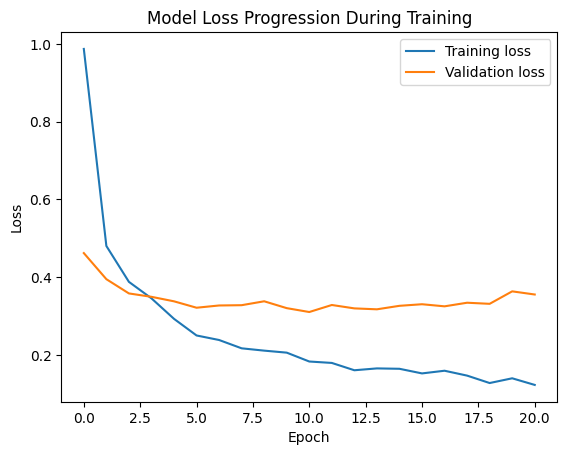

In [12]:
plt.title("Model Loss Progression During Training")
plt.plot(epochs_info.history['loss'])
plt.plot(epochs_info.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training loss", "Validation loss"])
plt.show()

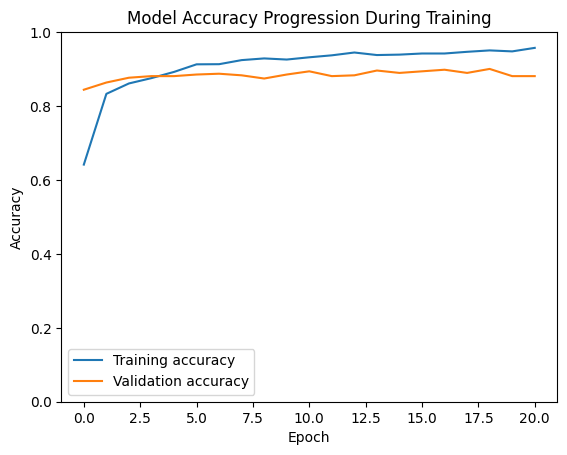

In [13]:
plt.title("Model Accuracy Progression During Training")
plt.plot(epochs_info.history['accuracy'])
plt.plot(epochs_info.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend(["Training accuracy", "Validation accuracy"])
plt.show()

## Model Evaluation

To evaluate our model we create a new data generator using the images previously separated in the "flower_photos_test" folder. Shuffling is disabled so that we can make predicted and actual labels paired for the confusion matrix.

Using TensorFlow's `evaluate` method, an accuracy of 89% is reported. This is quite good considering that we have only 3670 images and that some images seem to be incorrectly labeled, as shown later.

In [14]:
test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_flow = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False
)


Found 580 images belonging to 5 classes.


The confusion matrix below summarizes the predictions that our model has made for the 536 test images. The main diagonal has the correct classifications and remaining cells have the incorrect classifications.

The majority of predictions hit the main diagonal. We have mostly true positives, which indicates a very good performance for our model.

Our model makes a notable amount of mistakes saying that class 2 images (roses) belong to class 4 (tulips).

10/10 [==============================] - 7s 641ms/step


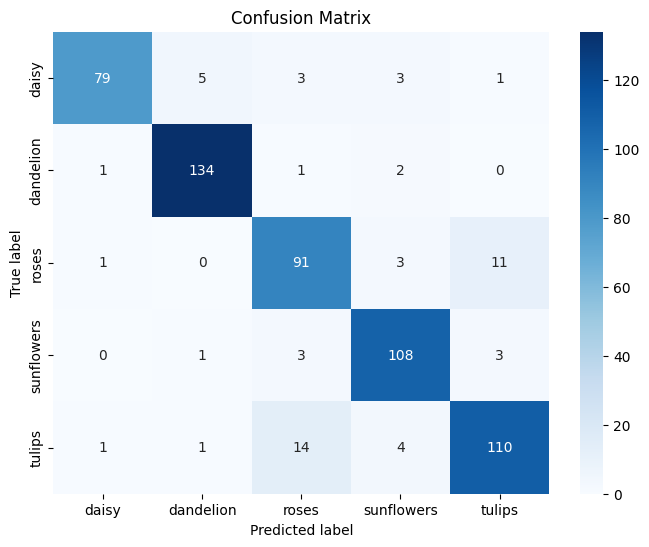

In [15]:
y_pred = resnet50_retrained.predict(test_flow)

# Lấy nhãn lớp dự đoán có xác suất cao nhất
y_pred_classes = np.argmax(y_pred, axis=1)

cf_matrix = confusion_matrix(test_flow.labels, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=test_flow.class_indices.keys(),
            yticklabels=test_flow.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

We can see that `classification_report` from Scikit-learn points to the same overall accuracy of 89%.

Class 4 has the worst precision performance due to the issue already discussed of class 2 members being predicted as class 4. These wrong predictions are false positives for class 4 and false negatives for class 2, hence the low recall for class 2.

In [16]:
print(classification_report(test_flow.labels, y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91        91
           1       0.95      0.97      0.96       138
           2       0.81      0.86      0.83       106
           3       0.90      0.94      0.92       115
           4       0.88      0.85      0.86       130

    accuracy                           0.90       580
   macro avg       0.90      0.90      0.90       580
weighted avg       0.90      0.90      0.90       580



Lastly, we build a grid of random images taken from the testing set. Along with the images, their actual and predicted labels are shown above them.

For the first error appearing in this grid, in line 3, column 1, there is a daisy flower mislabeled as a rose. Our model understood that it is a daisy. 

For the second error, in line 4, column 1, the sunflower is just a very small patch of a towel in the image. There are no actual flowers in the image.

Conclusively, our mistakes are understandable and our results are pretty good, considering that MobileNetV2 is a network proposed to be less accurate but also less resource intensive. In addition, since the quality of the images is good, it would be easy to perform data augmentation on this dataset. That would increase the number of available images and probably our model's performance.

Found 580 images belonging to 5 classes.
2/2 [==============================] - 3s 906ms/step


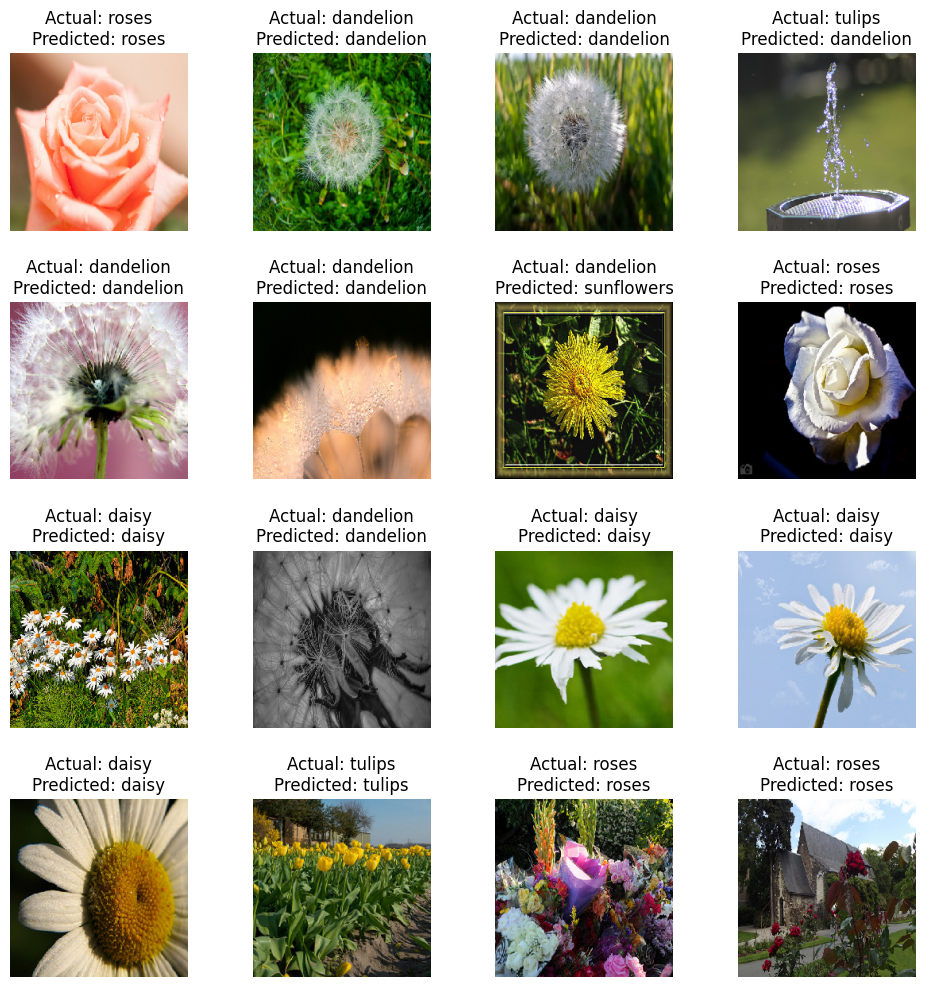

In [17]:
# Tạo generator mới để lấy ngẫu nhiên các ảnh kiểm thử (shuffle=True)
test_flow = test_datagen.flow_from_directory(
    test_dir,
    batch_size=batch_size,
    target_size=(224, 224),
    shuffle=True
)

grid_batch = test_flow.__getitem__(0)
batch_labels = encoder.inverse_transform(grid_batch[1]).flatten()

y_pred = resnet50_retrained.predict(grid_batch[0])
y_pred_classes = np.argmax(y_pred, axis=1)
predicted_labels = encoder.inverse_transform(y_pred).flatten()

fig, axes = plt.subplots(grid_height, grid_width, figsize=(12, 12))
axes = axes.ravel()

for i in range(grid_height * grid_width):
    drafted_index = np.random.randint(0, grid_batch[0].shape[0])
    
    # Giải chuẩn hóa trước khi gọi plt.imshow
    display_img = denormalize_image(grid_batch[0][drafted_index])
    axes[i].imshow(display_img)
    axes[i].set_title("Actual: " + str(batch_labels[drafted_index]) + "\nPredicted: " + str(predicted_labels[drafted_index]))
    axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

In [18]:
resnet50_retrained.save('my_flower_model_resnet50.keras') # Lưu model